
# Graph Fusion GNN Experiment

This notebook trains a **Graph Neural Network (GraphFusionNet)** using static and dynamic data features and evaluates its performance using t-SNE visualization.

---
### **Pipeline Overview**
1. Configuration  
2. Load dataset  
3. Label nodes  
4. Extract feature groups  
5. Normalize features  
6. Convert to tensors  
7. Create masks (train/val/test)  
8. Train model  
9. Evaluate and visualize embeddings


**GraphFusionNet-1 Architecture:**  
GraphFusionNet-1 is a dual-branch graph neural network designed to fuse node features from two distinct graphs sharing the same topology. Each input (`x1`, `x2`) passes through its own graph convolution layer (`gcn1_1`, `gcn1_2`) to produce hidden representations (`h1`, `h2`). These are combined using a learnable fusion weight α via a weighted sum \( h = αh_1 + (1 - α)h_2 \). The fused embedding `h` then passes through another pair of graph convolution layers (`gcn2_1`, `gcn2_2`), followed by a second fusion stage using the same α parameter to yield the final output. This design enables adaptive feature blending from multiple graph sources, enhancing joint representation learning.


**GraphFusionNet-1 Summary:**

- Designed for fusing static and dynamic graph data.  
- Inputs: node features `x1` (static), `x2` (dynamic), and shared `edge_index`.  
- Two parallel GCN layers extract features from both data sources. 
- Each branch has its own graph convolution layer (`gcn1_1` and `gcn1_2`).  
- Outputs from both branches (`h1`, `h2`) are combined using a learnable weight **α**.  
- Fusion equation:
  \( h = αh_1 + (1 - α)h_2 \).  
- A second GCN layer refines the fused representation into final output.  
- Returns either the fused embedding (`h`) or final output (`out`). 


In [88]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader


# Configuration


In [89]:
seed = 42
set_seed(seed)

num_epochs = 50

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'StaticDynamicGNN_adv_3'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "M22_Inductive_learning_exp"     

output_folder = f"results/inductive_learning/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [90]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [91]:
df_nodes.shape

(14640, 159)

# Label nodes

In [92]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [93]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [94]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [95]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [96]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [97]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [98]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [99]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [100]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [101]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )

# Inductive Learning

In [102]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [103]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [104]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [175]:
dynamic_tensor_norm.max()

tensor(1.)

Static normalization

In [106]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [107]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

# Inductive Split on nodes

In [108]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [109]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [110]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# Static–Dynamic GNN layer

In [111]:
conv_layer = GraphConv  # SAGEConv, GraphConv, GCNConv

In [112]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing


class StaticDynamicGNN(MessagePassing):
    def __init__(self, in_static, window_size, hidden_dim, out_dim, dropout=0.2):  #0.2
        super().__init__(aggr="add")

        hidden_dim_2 = 64
        self.dropout = dropout

        # ---- Self projections ----
        self.lin_stat_self = nn.Linear(in_static, hidden_dim)
        self.lin_dyn_self = nn.Linear(window_size, hidden_dim)

        # ---- Neighbor projections ----
        self.lin_stat_neigh = nn.Linear(in_static, hidden_dim)
        self.lin_dyn_neigh = nn.Linear(window_size, hidden_dim)

        # ---- Node-level vector gates ----
        self.gate_self = nn.Linear(2*hidden_dim, 1)
        self.gate_neigh = nn.Linear(2*hidden_dim, 1)

        # ---- Fusion update ----
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim_2),
            nn.ReLU(),
            # nn.LeakyReLU(0.1),
        )

        self.norm = nn.LayerNorm(hidden_dim_2)    # new

        self.classif_mlp = nn.Sequential(
            nn.Linear(hidden_dim_2, 128),
            nn.ReLU(),
            # nn.LeakyReLU(0.1),
            nn.Linear(128, 1)
        )

        # Storage for explainability
        self.last_gate_self = None
        self.last_gate_neigh = None

        self.reset_parameters()

    def reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    # -------- Message passing --------
    def message(self, x_static_j, x_dynamic_j):

        stat = self.lin_stat_neigh(x_static_j)
        dyn = self.lin_dyn_neigh(x_dynamic_j)

        gate_input = torch.cat([stat, dyn], dim=-1)

        gate = torch.sigmoid(self.gate_neigh(gate_input))   # (num_edges, 1)

        # Store for explainability (detach to avoid graph growth)
        self.last_gate_neigh = gate.detach()

        fused = gate * stat + (1 - gate) * dyn

        return fused

    # -------- Update --------
    def update(self, aggr_out, x_static, x_dynamic):

        stat = self.lin_stat_self(x_static)
        dyn = self.lin_dyn_self(x_dynamic)

        gate_input = torch.cat([stat, dyn], dim=-1)

        gate = torch.sigmoid(self.gate_self(gate_input))   # (num_nodes, 1)

        # Store for explainability
        self.last_gate_self = gate.detach()

        

        self_emb = gate * stat + (1 - gate) * dyn

        fused = torch.cat([self_emb, aggr_out], dim=-1)

        hidden = self.update_mlp(fused)
        # hidden = self.norm(hidden)      #new
        
        hidden = F.dropout(hidden, p=self.dropout, training=self.training)
        # hidden = hidden + self_emb      #new

        return hidden

    # -------- Forward --------
    def forward(self, x_static, x_dynamic, edge_index, return_embedding=False):

        hidden = self.propagate(
            edge_index,
            x_static=x_static,
            x_dynamic=x_dynamic
        )

        out = self.classif_mlp(hidden)

        # if return_embedding:
        #     return out.squeeze(-1), hidden

        return out.squeeze(-1), hidden


In [113]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch_geometric.nn import MessagePassing


# class StaticDynamicGNN(MessagePassing):
#     def __init__(self, in_static, window_size, hidden_dim, out_dim, dropout=0.2):
#         super().__init__(aggr="add")

#         self.hidden_dim = hidden_dim
#         self.dropout = dropout

#         hidden_dim_2 = 64

#         # -----------------------------
#         # Feature projections
#         # -----------------------------
#         self.lin_stat_self = nn.Linear(in_static, hidden_dim)
#         self.lin_dyn_self = nn.Linear(window_size, hidden_dim)

#         self.lin_stat_neigh = nn.Linear(in_static, hidden_dim)
#         self.lin_dyn_neigh = nn.Linear(window_size, hidden_dim)

#         # -----------------------------
#         # Gating networks
#         # -----------------------------
#         self.gate_self = nn.Linear(2 * hidden_dim, 1)
#         self.gate_neigh = nn.Linear(2 * hidden_dim, 1)

#         # Initialize gates to prefer stability (important for magnitude)
#         # nn.init.constant_(self.gate_self.bias, 1.0)
#         # nn.init.constant_(self.gate_neigh.bias, 1.0)

#         # -----------------------------
#         # Fusion MLP
#         # -----------------------------
#         self.update_mlp = nn.Sequential(
#             nn.Linear(2 * hidden_dim, hidden_dim_2),
#             nn.ReLU(),
#             nn.Linear(hidden_dim_2, hidden_dim_2),
#             nn.ReLU(),
#         )

#         # -----------------------------
#         # Output head
#         # -----------------------------
#         self.classif_mlp = nn.Sequential(
#             nn.Linear(hidden_dim_2, 128),
#             nn.ReLU(),
#             nn.Linear(128, 1)
#         )

#         # Learned output scaling (VERY IMPORTANT for magnitude recovery)
#         self.out_scale = nn.Parameter(torch.tensor(1.0))
#         self.out_bias = nn.Parameter(torch.tensor(0.0))

#         # Explainability storage
#         self.last_gate_self = None
#         self.last_gate_neigh = None

#         self.reset_parameters()

#     def reset_parameters(self):
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.xavier_uniform_(m.weight)
#                 nn.init.zeros_(m.bias)

#     # -----------------------------
#     # Message passing
#     # -----------------------------
#     def message(self, x_static_j, x_dynamic_j):

#         stat = self.lin_stat_neigh(x_static_j)
#         dyn = self.lin_dyn_neigh(x_dynamic_j)

#         gate_input = torch.cat([stat, dyn], dim=-1)

#         # sharpen gate slightly (prevents averaging collapse)
#         gate = torch.sigmoid(self.gate_neigh(gate_input) / 0.7)

#         self.last_gate_neigh = gate.detach()

#         # IMPORTANT FIX:
#         # avoid convex collapse → use additive form
#         fused = stat + gate * dyn
#         # fused = gate * x_static_j + (1-gate) * x_dynamic_j

#         return fused

#     # -----------------------------
#     # Update
#     # -----------------------------
#     def update(self, aggr_out, x_static, x_dynamic):

#         stat = self.lin_stat_self(x_static)
#         dyn = self.lin_dyn_self(x_dynamic)

#         gate_input = torch.cat([stat, dyn], dim=-1)

#         gate = torch.sigmoid(self.gate_self(gate_input) / 0.7)

#         self.last_gate_self = gate.detach()

#         # IMPORTANT FIX:
#         # additive fusion instead of convex combination
#         self_emb = stat + gate * dyn
#         # self_emb = gate * x_static + (1-gate) * x_dynamic

#         # fused = torch.cat([self_emb, aggr_out], dim=-1)
#         fused = torch.cat([self_emb, aggr_out], dim=-1)

#         hidden = self.update_mlp(fused)

#         # -----------------------------
#         # CRITICAL FIX: residual connection
#         # (prevents magnitude shrinkage)
#         # -----------------------------
#         hidden = hidden + self_emb

#         hidden = F.dropout(hidden, p=self.dropout, training=self.training)

#         return hidden

#     # -----------------------------
#     # Forward
#     # -----------------------------
#     def forward(self, x_static, x_dynamic, edge_index, return_embedding=False):

#         hidden = self.propagate(
#             edge_index,
#             x_static=x_static,
#             x_dynamic=x_dynamic
#         )

#         out = self.classif_mlp(hidden)

#         # -----------------------------
#         # CRITICAL FIX: learned scaling
#         # restores amplitude of predictions
#         # -----------------------------
#         out = self.out_scale * out + self.out_bias

#         if return_embedding:
#             return out.squeeze(-1), hidden

#         return out.squeeze(-1), hidden

# Single layer Model

In [114]:
class CrimeForecastModel(nn.Module):
    def __init__(self, in_static, window_size, hidden_dim):
        super().__init__()
        self.gnn = StaticDynamicGNN(
            in_static=in_static,
            window_size=window_size,
            hidden_dim=hidden_dim,
            out_dim=1
        )

    def forward(self, x_static, x_dynamic, edge_index, return_embedding = False):
        return self.gnn(x_static, x_dynamic, edge_index, return_embedding)


In [115]:
S = static_tensor.size(1)

# Model initialization and optimizer

In [116]:
model = CrimeForecastModel(
    in_static=S,
    window_size=W,
    hidden_dim=64
)

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay= 1e-5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [117]:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [118]:
patience = 5
min_delta = 1e-6
best_loss = float("inf")
epochs_no_improve = 0


alpha_self_history = []
alpha_neigh_history = []
train_loss_per_epoch = []
test_loss_per_epoch = []

criterion = nn.MSELoss()
# num_epochs = 5
for epoch in range(num_epochs):

    train_loss = train_epoch_in(model, train_loader, optimizer, criterion, "cpu")
    train_loss_per_epoch.append(train_loss)

    # ---- After training epoch, extract gates from last batch ----
    with torch.no_grad():

        gates_self = model.gnn.last_gate_self
        gates_neigh = model.gnn.last_gate_neigh

        if gates_self is not None:
            alpha_self_mean = gates_self.mean().item()
        else:
            alpha_self_mean = 0.0

        if gates_neigh is not None:
            alpha_neigh_mean = gates_neigh.mean().item()
        else:
            alpha_neigh_mean = 0.0

        alpha_self_history.append(alpha_self_mean)
        alpha_neigh_history.append(alpha_neigh_mean)

    # ---- Evaluate ----
    test_loss, _, _ = evaluate_and_collect(model, test_loader, "cpu")
    current_loss = test_loss["MSE"]
    test_loss_per_epoch.append(test_loss)

    # 🔷 Early stopping logic
    if current_loss < best_loss - min_delta:
        best_loss = current_loss
        epochs_no_improve = 0
        best_state = model.state_dict()  # save best model
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Self → Static Mean: {alpha_self_mean:.3f}, "
        f"Dynamic Mean: {1 - alpha_self_mean:.3f} | "
        f"Neigh → Static Mean: {alpha_neigh_mean:.3f}, "
        f"Dynamic Mean: {1 - alpha_neigh_mean:.3f} | "
        f"Test: {test_loss['MSE']:.4f}"
    )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# 🔷 Load best model after training
model.load_state_dict(best_state)


Epoch 00 | Train: 0.0403 | Self → Static Mean: 0.554, Dynamic Mean: 0.446 | Neigh → Static Mean: 0.498, Dynamic Mean: 0.502 | Test: 0.0043
Epoch 01 | Train: 0.0054 | Self → Static Mean: 0.552, Dynamic Mean: 0.448 | Neigh → Static Mean: 0.493, Dynamic Mean: 0.507 | Test: 0.0032
Epoch 02 | Train: 0.0033 | Self → Static Mean: 0.550, Dynamic Mean: 0.450 | Neigh → Static Mean: 0.489, Dynamic Mean: 0.511 | Test: 0.0023
Epoch 03 | Train: 0.0020 | Self → Static Mean: 0.547, Dynamic Mean: 0.453 | Neigh → Static Mean: 0.485, Dynamic Mean: 0.515 | Test: 0.0015
Epoch 04 | Train: 0.0015 | Self → Static Mean: 0.543, Dynamic Mean: 0.457 | Neigh → Static Mean: 0.483, Dynamic Mean: 0.517 | Test: 0.0011
Epoch 05 | Train: 0.0011 | Self → Static Mean: 0.540, Dynamic Mean: 0.460 | Neigh → Static Mean: 0.480, Dynamic Mean: 0.520 | Test: 0.0009
Epoch 06 | Train: 0.0009 | Self → Static Mean: 0.536, Dynamic Mean: 0.464 | Neigh → Static Mean: 0.478, Dynamic Mean: 0.522 | Test: 0.0008
Epoch 07 | Train: 0.0008 | 

<All keys matched successfully>

# Mean Gate Contribution across epochs

In [119]:
epochs = np.arange(len(alpha_self_history))

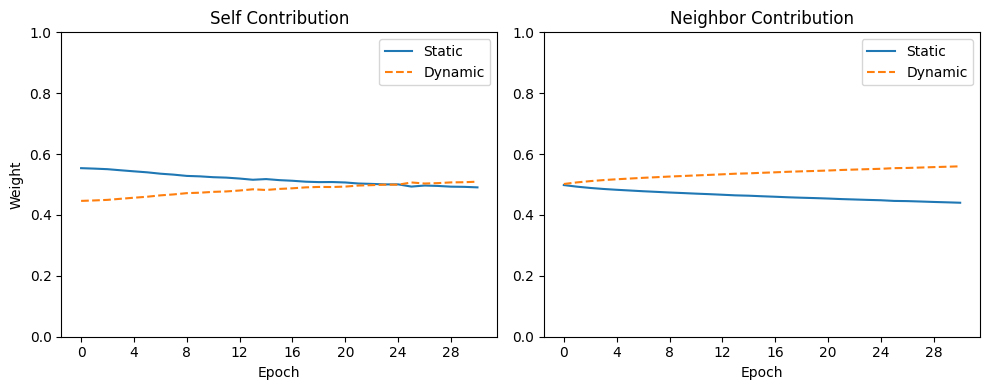

In [120]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, alpha_self_history, label="Static")
plt.plot(epochs, [1 - a for a in alpha_self_history], label="Dynamic", linestyle="--")
plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
plt.title("Self Contribution")
plt.xlabel("Epoch")
plt.ylabel("Weight")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, alpha_neigh_history, label="Static")
plt.plot(epochs, [1 - a for a in alpha_neigh_history], label="Dynamic", linestyle="--")

plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
plt.title("Neighbor Contribution")
plt.xlabel("Epoch")
plt.legend()
# plt.grid(True)

plt.tight_layout()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"contribution_{model_used}.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


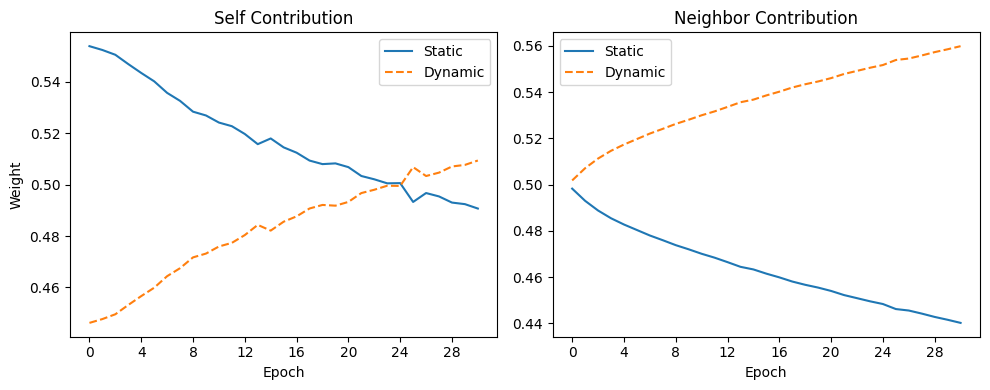

In [121]:
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import numpy as np



plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, alpha_self_history, label="Static")
plt.plot(epochs, [1 - a for a in alpha_self_history], label="Dynamic", linestyle="--")
# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
plt.title("Self Contribution")
plt.xlabel("Epoch")
plt.ylabel("Weight")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, alpha_neigh_history, label="Static")
plt.plot(epochs, [1 - a for a in alpha_neigh_history], label="Dynamic", linestyle="--")

# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
plt.title("Neighbor Contribution")
plt.xlabel("Epoch")
plt.legend()
# plt.grid(True)

plt.tight_layout()
# plt.show()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"contribution_zoom_{model_used}.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


# Explainability

## Collect Gates over entire dataset

In [122]:
# def collect_explainability(model, loader, device):

#     model.eval()

#     all_node_ids = []
#     all_time_ids = []
#     all_gate_self = []
#     all_gate_neigh = []

#     with torch.no_grad():
#         for data in loader:
#             data = data.to(device)

#             _ = model(
#                 data.x_static,
#                 data.x_dynamic,
#                 data.edge_index
#             )

#             gate_self = model.last_gate_self.squeeze().cpu()
#             gate_neigh = model.last_gate_neigh.squeeze().cpu()

#             all_node_ids.append(data.node_ids.cpu())
#             all_time_ids.append(data.time_id.cpu())
#             all_gate_self.append(gate_self)
#             all_gate_neigh.append(gate_neigh)

#     return {
#         "node_ids": torch.cat(all_node_ids),
#         "time_ids": torch.cat(all_time_ids),
#         "gate_self": torch.cat(all_gate_self),
#         "gate_neigh": torch.cat(all_gate_neigh)
#     }


In [123]:
def collect_explainability(model, loader, device):

    model.eval()

    all_node_ids = []
    all_time_ids = []
    all_gate_self = []
    all_gate_neigh = []
    all_crime = []   # 🔥 NEW

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            _ = model(
                data.x_static,
                data.x_dynamic,
                data.edge_index
            )

            # ✅ Correct access
            gate_self = model.last_gate_self.squeeze().cpu()
            gate_neigh = model.last_gate_neigh.squeeze().cpu()

            # ✅ Crime intensity (window aggregation)
            crime = data.x_dynamic.mean(dim=1).cpu()

            all_node_ids.append(data.node_ids.cpu())
            all_time_ids.append(data.time_id.cpu())
            all_gate_self.append(gate_self)
            all_gate_neigh.append(gate_neigh)
            all_crime.append(crime)

    return {
        "node_ids": torch.cat(all_node_ids),
        "time_ids": torch.cat(all_time_ids),
        "gate_self": torch.cat(all_gate_self),
        "gate_neigh": torch.cat(all_gate_neigh),
        "crime": torch.cat(all_crime)   # 🔥 NEW
    }

In [124]:
results = collect_explainability(model.gnn, test_loader, "cpu")


In [125]:
results['gate_self'].shape

torch.Size([570960])

In [126]:
# def compare_low_high_crime(results, threshold=0.1):
#     gates = results["gate_self"]
#     crime = results["crime"]

#     low = gates[crime < threshold]
#     high = gates[crime >= threshold]

#     print("Low crime gate mean:", low.mean().item())
#     print("High crime gate mean:", high.mean().item())

# compare_low_high_crime(results, threshold=0.8)

In [127]:
gates = results["gate_self"].numpy()
gates.shape


(570960,)

Correlation (crime vs gate): -0.8148


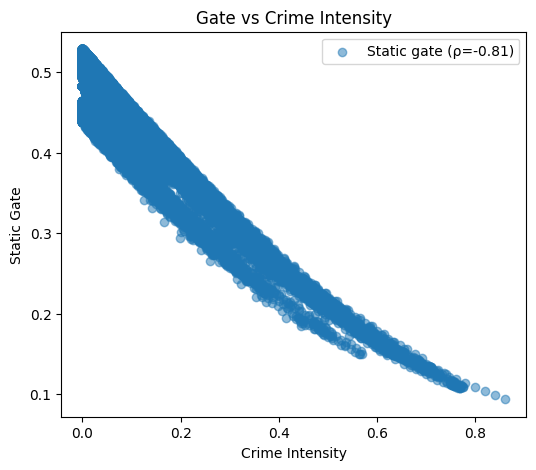

In [128]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_gate_vs_crime(results, filename = "crime_inetesity_vs_static_gate", output_path = None):
    gates = results["gate_self"].numpy()
    crime = results["crime"].numpy()

    # ---- Correlation ----
    corr = np.corrcoef(crime, gates)[0,1]
    print(f"Correlation (crime vs gate): {corr:.4f}")

    # ---- Scatter ----
    plt.figure(figsize=(6,5))
    plt.scatter(crime, gates, alpha=0.5, label = f"Static gate (ρ={corr:.2f})" )
    plt.xlabel("Crime Intensity")
    plt.ylabel("Static Gate")
    plt.title("Gate vs Crime Intensity")
    plt.legend()
    # plt.show()
    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()

analyze_gate_vs_crime(results, filename = f"crime_inetesity_vs_static_gate_{model_used}", output_path = output_folder)

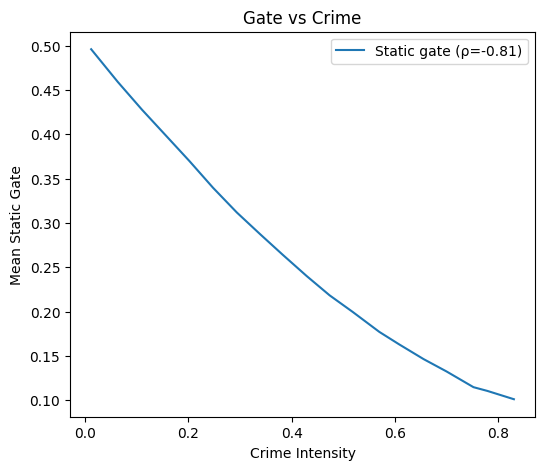

In [129]:
def plot_binned_gate(results, bins=20, filename = "crime_inetesity_vs_gates", output_path = None):
    gates = results["gate_self"].numpy()
    crime = results["crime"].numpy()

    corr_static = np.corrcoef(crime, gates)[0,1]
    corr_dynamic = np.corrcoef(crime, [1-x for x in gates])[0,1]

    bins_edges = np.linspace(crime.min(), crime.max(), bins)
    digitized = np.digitize(crime, bins_edges)

    means = []
    centers = []

    for i in range(1, bins):
        mask = digitized == i
        if np.sum(mask) > 0:
            means.append(gates[mask].mean())
            centers.append(crime[mask].mean())
    
    

    plt.figure(figsize=(6,5))
    # plt.plot(centers, means, marker='o')
    plt.plot(centers, means, label = f"Static gate (ρ={corr_static:.2f})")
    # plt.plot(centers, [1 - x for x in means], label = f"Dynamic gate (ρ={corr_dynamic:.2f})")
    plt.xlabel("Crime Intensity")
    plt.ylabel("Mean Static Gate")
    plt.title("Gate vs Crime")
    plt.legend()
    # plt.show() 

    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()

plot_binned_gate(results, bins=20, filename = f"crime_inetesity_vs_gates_without_dynamic_{model_used}", output_path = output_folder)

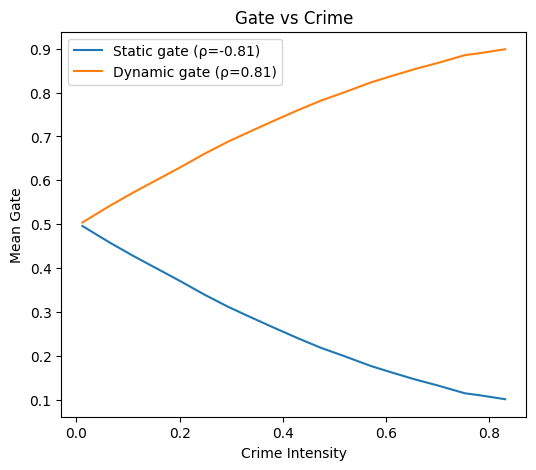

In [130]:
def plot_binned_gate(results, bins=20, filename = "crime_inetesity_vs_gates", output_path = None):
    gates = results["gate_self"].numpy()
    crime = results["crime"].numpy()

    corr_static = np.corrcoef(crime, gates)[0,1]
    corr_dynamic = np.corrcoef(crime, [1-x for x in gates])[0,1]

    bins_edges = np.linspace(crime.min(), crime.max(), bins)
    digitized = np.digitize(crime, bins_edges)

    means = []
    centers = []

    for i in range(1, bins):
        mask = digitized == i
        if np.sum(mask) > 0:
            means.append(gates[mask].mean())
            centers.append(crime[mask].mean())
    
    

    plt.figure(figsize=(6,5))
    # plt.plot(centers, means, marker='o')
    plt.plot(centers, means, label = f"Static gate (ρ={corr_static:.2f})")
    plt.plot(centers, [1 - x for x in means], label = f"Dynamic gate (ρ={corr_dynamic:.2f})")
    plt.xlabel("Crime Intensity")
    plt.ylabel("Mean Gate")
    plt.title("Gate vs Crime")
    plt.legend()
    # plt.show() 

    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()

plot_binned_gate(results, bins=20, filename = f"crime_inetesity_vs_gates_{model_used}", output_path = output_folder)

# Global Modality Contribution

In [131]:
def global_analysis(results):

    g = results["gate_self"]
    neig = results["gate_neigh"]

    print("----- Global Modality Contribution -----")
    print("Static Mean:", round(g.mean().item(), 3))
    print("Dynamic Mean:", round(1 - g.mean().item(), 3))
    print("Std Dev:", round(g.std().item(), 3))

    print("----- Global Neighbor Contribution -----")
    print("Static Mean:", round(neig.mean().item(), 3))
    print("Dynamic Mean:", round(1 - neig.mean().item(), 3))
    print("Std Dev:", round(neig.std().item(), 3))


In [132]:
global_analysis(results)


----- Global Modality Contribution -----
Static Mean: 0.484
Dynamic Mean: 0.516
Std Dev: 0.042
----- Global Neighbor Contribution -----
Static Mean: 0.439
Dynamic Mean: 0.561
Std Dev: 0.019


## Spatial Analysis (Per Node)

In [133]:
def spatial_analysis(results, num_nodes):

    node_ids = results["node_ids"]
    gates = results["gate_self"]

    node_sum = torch.zeros(num_nodes)
    node_count = torch.zeros(num_nodes)

    for nid, g in zip(node_ids, gates):
        node_sum[nid] += g
        node_count[nid] += 1

    node_mean = node_sum / node_count

    return node_mean

def compute_node_gate_stats(results):
    gates = results["gate_self"]
    # gates = results["gate_neigh"]
    node_ids = results["node_ids"]

    unique_nodes = torch.unique(node_ids)

    node_means = {}

    for node in unique_nodes:
        mask = node_ids == node
        node_means[node.item()] = gates[mask].mean().item()

    return node_means


In [134]:
node_gate = spatial_analysis(results, num_nodes=num_nodes)
node_means = compute_node_gate_stats(results)


In [135]:
print(len(node_gate))
node_ids = results["node_ids"]
gates = results["gate_self"]
print(len(node_ids))
print(len(gates))


14640
570960
570960


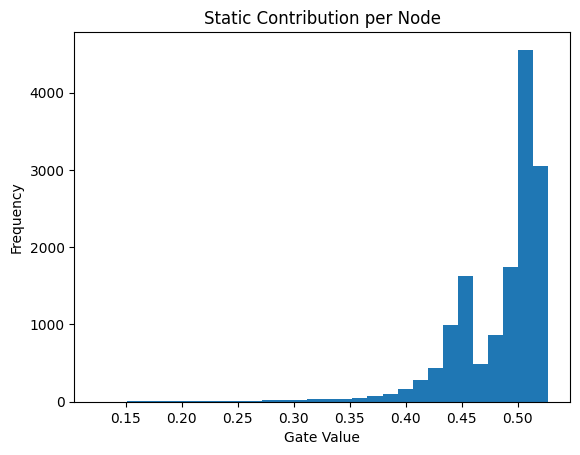

In [136]:
import matplotlib.pyplot as plt

plt.hist(node_gate.numpy(), bins=30)
plt.title("Static Contribution per Node")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()


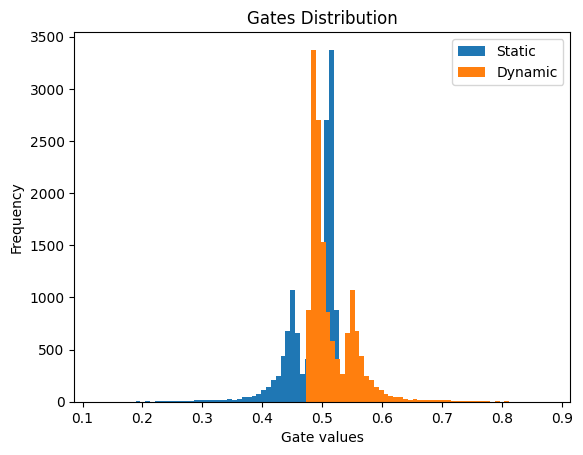

In [137]:
def plot_node_distribution(node_means, output_path):
    import matplotlib.pyplot as plt

    values = list(node_means.numpy())
    # values = list(node_means.values())

    plt.hist(values, bins=50, label="Static")
    plt.hist([1 - x for x in values], bins=50, label='Dynamic')
    plt.title("Gates Distribution")
    plt.xlabel("Gate values")
    plt.ylabel("Frequency")
    plt.legend()

    if output_path:
        file_path = os.path.join(output_path, f"Gate distribution_{model_used}.{save_format}")
        plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()
        plt.close()
    

plot_node_distribution(node_gate, output_path=output_folder)
# plot_node_distribution(node_means, output_path=output_folder)


# Temporal Analysis

In [138]:
# len(results["gate_self"])
time_ids = results["time_ids"]
time_ids

tensor([100, 100, 100,  ..., 138, 138, 138])

In [139]:
def temporal_analysis(results):

    time_ids = results["time_ids"]
    gates = results["gate_self"]

    unique_times = torch.unique(time_ids)
    time_means = []

    for t in unique_times:
        mask = time_ids == t
        time_means.append(gates[mask].mean().item())

    return unique_times.cpu(), time_means


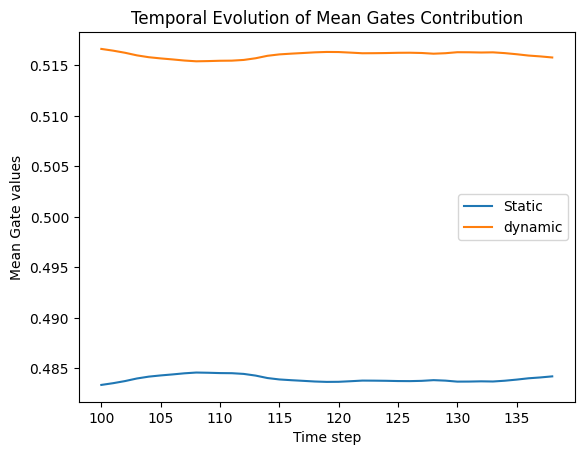

In [140]:
times, means = temporal_analysis(results)

plt.plot(times.numpy(), means, label="Static")
plt.plot(times.numpy(), [1-x for x in means], label="dynamic")
plt.title("Temporal Evolution of Mean Gates Contribution")
plt.xlabel("Time step")
plt.ylabel("Mean Gate values")
plt.legend()
# plt.show()
# if output_path:
file_path = os.path.join(output_folder, f"mean_gate_values_across_time_{model_used}.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# else:
# plt.show()
# plt.close()


# Node level analysis

#

In [141]:


def select_representative_nodes(node_means, k=3):
    import numpy as np

    nodes = list(node_means.keys())
    values = np.array(list(node_means.values()))

    sorted_idx = np.argsort(values)

    low_nodes = [nodes[i] for i in sorted_idx[:k]]        # dynamic-heavy
    high_nodes = [nodes[i] for i in sorted_idx[-k:]]      # static-heavy
    mid_nodes = [nodes[i] for i in sorted_idx[len(nodes)//2 - k//2 : len(nodes)//2 + k//2]]

    return low_nodes, mid_nodes, high_nodes

def plot_selected_nodes(results, selected_nodes):
    gates = results["gate_self"]
    node_ids = results["node_ids"]
    time_ids = results["time_ids"]

    plt.figure()

    for node in selected_nodes:
        mask = node_ids == node
        plt.plot(time_ids[mask], gates[mask], label=f"Node {node}")

    plt.legend()
    plt.title("Representative Node Gate Behavior")
    plt.xlabel("Time")
    plt.ylabel("Static Gate")
    plt.show()

Dynamic-heavy nodes: [397, 451, 392]
Balanced nodes: [12077, 14386]
Static-heavy nodes: [8573, 8584, 6370]


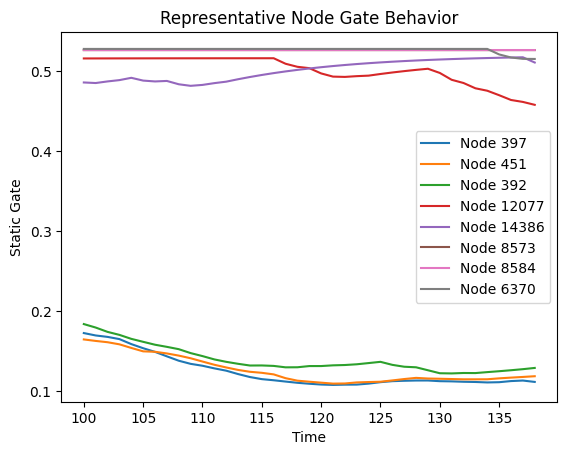

In [142]:
node_means = compute_node_gate_stats(results)

low, mid, high = select_representative_nodes(node_means, k =3)

print("Dynamic-heavy nodes:", low)
print("Balanced nodes:", mid)
print("Static-heavy nodes:", high)

plot_selected_nodes(results, low + mid + high)

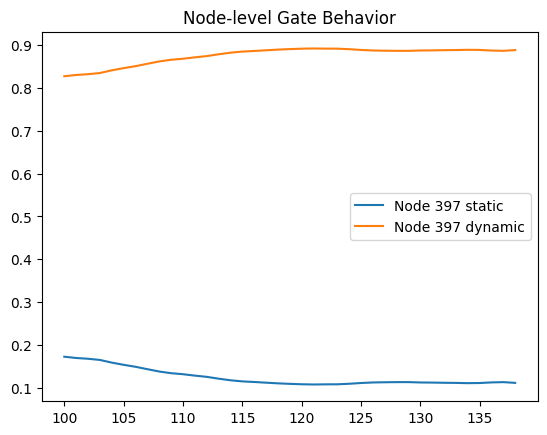

In [143]:
def plot_node_variation(results, nodes = 397, filename = "gate_variation_across_node", output_path = None):
    gates = results["gate_self"]
    node_ids = results["node_ids"]
    time_ids = results["time_ids"]

    unique_nodes = torch.unique(node_ids)

    # for node in unique_nodes[:num_nodes]:
    for node in [nodes]:
        mask = node_ids == node
        plt.plot(time_ids[mask], gates[mask], label=f"Node {node} static")
        plt.plot(time_ids[mask], 1 - gates[mask], label=f"Node {node} dynamic")

    plt.legend()
    plt.title("Node-level Gate Behavior")

    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()
    
    # plt.show()

plot_node_variation(results, nodes=397, filename= f"node_level_gate_behaviour_{model_used}", output_path= output_folder)
# Dynamic-heavy nodes: [397, 451, 392]
# Balanced nodes: [1946, 9381]
# Static-heavy nodes: [8573, 8584, 6370]

In [144]:
values = list(node_means.values())

extreme_static = sum(v > 0.6 for v in values) / len(values)
extreme_dynamic = sum(v < 0.4 for v in values) / len(values)

print("Strong static nodes:", extreme_static)
print("Strong dynamic nodes:", extreme_dynamic)

Strong static nodes: 0.0
Strong dynamic nodes: 0.03415300546448088


In [145]:
values = list(node_means.values())

print("Min:", min(values), np.argmin(values))
print("Max:", max(values), np.argmax(values))

Min: 0.1240822970867157 397
Max: 0.5268643498420715 6370


# Gradient validation

In [146]:
def gradient_validation(model, data, device):

    model.eval()

    data = data.to(device)

    data.x_static.requires_grad = True
    data.x_dynamic.requires_grad = True

    pred, _ = model(
        data.x_static,
        data.x_dynamic,
        data.edge_index
    )

    loss = pred.sum()
    loss.backward()

    static_grad = data.x_static.grad.abs().mean().item()
    dynamic_grad = data.x_dynamic.grad.abs().mean().item()

    print("Static Gradient:", static_grad)
    print("Dynamic Gradient:", dynamic_grad)


In [147]:
data_sample = next(iter(test_loader))
gradient_validation(model.gnn, data_sample, "cpu")


Static Gradient: 0.014289956539869308
Dynamic Gradient: 0.13940982520580292


# Predicted Time Series Analysis

In [148]:
def plot_fluctuation_analysis(
    pred_matrix,
    targ_matrix,
    node,
    adj,
    max_hop=2,
    mode="mean",
    output_path=None,
    filename=None,
    show_correlation=True
):
    """
    pred_matrix : shape (T, N)
    targ_matrix : shape (T, N)
    node        : central node id
    adj         : adjacency dictionary
    max_hop     : number of hops
    mode        : "mean" or "all"
    show_correlation : display correlation values in plot
    """

    T = pred_matrix.shape[0]
    time = np.arange(T)

    plt.figure(figsize=(8, 5))

    # ---- Central target node ----
    central_tar = targ_matrix[:, node]
    plt.plot(
        time,
        central_tar,
        linewidth=3,
        color="green",
        label=f"Node {node} (original)"
    )

    # ---- Central predicted node ----
    central = pred_matrix[:, node]
    plt.plot(
        time,
        central,
        linewidth=3,
        color="red",
        label=f"Node {node} (predicted)"
    )
    

    hop_colors = plt.cm.viridis(np.linspace(0.3, 0.9, max_hop))

    correlations = []

    for hop in range(1, max_hop + 1):

        neighbors = get_neighbors(node, adj, order=hop)

        if len(neighbors) == 0:
            continue

        color = hop_colors[hop - 1]

        # Mean series for hop
        hop_series = pred_matrix[:, neighbors].mean(axis=1)

        # ---- Correlation ----
        corr = np.corrcoef(central, hop_series)[0, 1]
        correlations.append((hop, corr))

        if mode == "mean":

            plt.plot(
                time,
                hop_series,
                linewidth=2,
                linestyle="--",
                color=color,
                label=f"Mean {hop}-hop (ρ={corr:.2f})"
            )

        elif mode == "all":

            for n in neighbors:
                plt.plot(
                    time,
                    pred_matrix[:, n],
                    linewidth=1.5,
                    alpha=0.4,
                    color=color
                )

            # One legend entry
            plt.plot(
                [],
                [],
                color=color,
                linewidth=2,
                label=f"{hop}-hop (ρ={corr:.2f})"
            )

    plt.xlabel("Time Step")
    plt.ylabel("Crime Intensity")
    plt.title("Spatio-Temporal Crime Evolution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # # Optional: correlation text box
    # if show_correlation and correlations:
    #     corr_text = "\n".join(
    #         [f"{hop}-hop ρ = {corr:.3f}" for hop, corr in correlations]
    #     )
    #     plt.gcf().text(
    #         0.85, 0.75,
    #         corr_text,
    #         fontsize=10,
    #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
    #     )

    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()




In [149]:
metrics, preds_per_t, targets_per_t = evaluate_and_collect(
    model, test_loader, device = 'cpu'
    # model, train_loader, device = 'cpu'
)

print(metrics)

{'MSE': 0.00025516856112517416, 'RMSE': np.float64(0.015973996404318305), 'MAE': 0.009187165647745132, 'R2': 0.9120489358901978, 'huber': 0.00012758426601067185}


In [150]:
import pandas as pd

df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
df.to_csv(f"{output_folder}/metrics_results_{model_used}.csv", index=False, float_format="%.6f")

# Select representative node using high, low, medium gate values

In [151]:
low, mid, high = select_representative_nodes(node_means, k =5)

In [152]:
# preds_per_t = torch.sigmoid(preds_per_t)

In [153]:
# adj = build_adj(edge_index)
adj = build_adj(test_dataset[0].edge_index)

pred_matrix = np.stack(preds_per_t)
target_mat = np.stack(targets_per_t)

In [154]:
print(low)
print(mid)
print(high)

[397, 451, 392, 664, 11893]
[10105, 12077, 14386, 8858]
[10289, 13673, 8573, 8584, 6370]


In [155]:
# selected_node = 12024

In [156]:
# plot_fluctuation_analysis(pred_matrix, target_mat, selected_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'node_{selected_node}_evolution_{model_used}')
# plot_node_variation(results, nodes=selected_node, filename= f"node_{selected_node}_gate_behaviour_{model_used}", output_path= output_folder)


## Choose High Crime Node

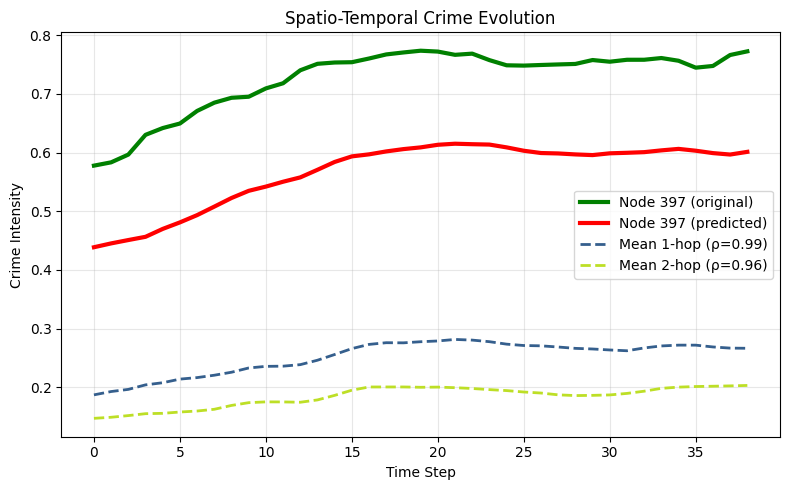

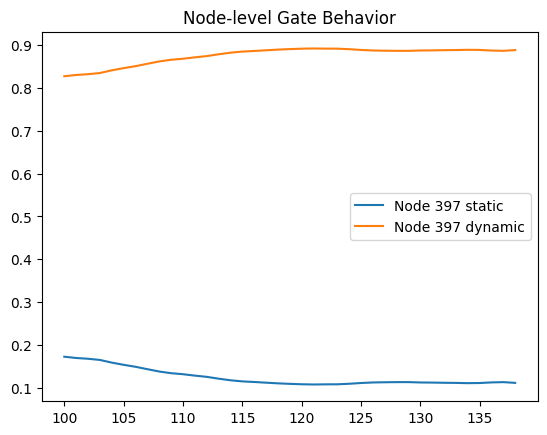

In [176]:
# adj = build_adj(edge_index)
adj = build_adj(test_dataset[0].edge_index)

pred_matrix = np.stack(preds_per_t)
target_mat = np.stack(targets_per_t)


# Choose high-crime node
avg_pred_per_node = pred_matrix.mean(axis=0)
high_node = np.argmax(avg_pred_per_node)
high_node = 397

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')
plot_node_variation(results, nodes=high_node, filename= f"node_level_gate_behaviour_{model_used}", output_path= output_folder)



In [158]:
node = high_node

neighbors_1 = get_neighbors(node, adj, order=1)
neighbors_2 = get_neighbors(node, adj, order=2)

print("Central node:", node)
print("1-hop:", neighbors_1)
print("2-hop:", neighbors_2)
print("Number of 1-hop nodes:", len(neighbors_1))
print("Number of 2-hop nodes:", len(neighbors_2))

print(
    "Central == 1-hop mean:",
    np.allclose(
        pred_matrix[:, node],
        pred_matrix[:, neighbors_1].mean(axis=1)
    )
)

print(
    "Central == 2-hop mean:",
    np.allclose(
        pred_matrix[:, node],
        pred_matrix[:, neighbors_2].mean(axis=1)
    )
)

Central node: 451
1-hop: [np.int64(450), np.int64(422), np.int64(423)]
2-hop: [np.int64(449), np.int64(450), np.int64(422), np.int64(423), np.int64(392), np.int64(424), np.int64(394), np.int64(10965), np.int64(438), np.int64(475)]
Number of 1-hop nodes: 3
Number of 2-hop nodes: 10
Central == 1-hop mean: False
Central == 2-hop mean: False


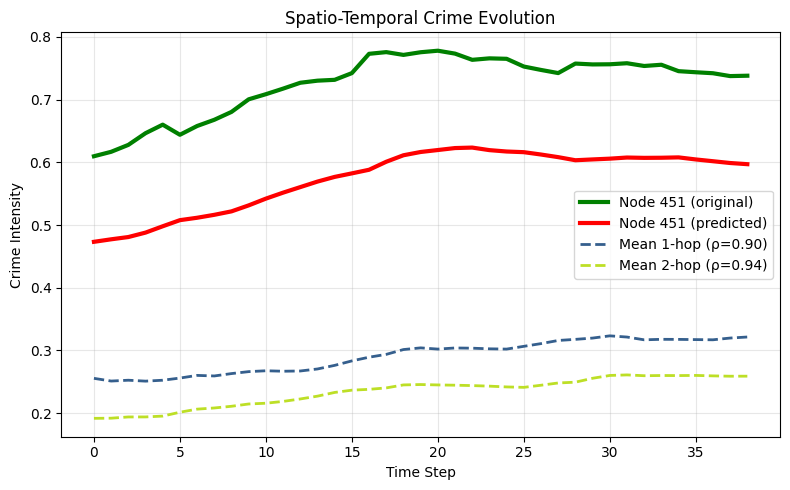

In [159]:
# adj = build_adj(edge_index)
adj = build_adj(test_dataset[0].edge_index)

pred_matrix = np.stack(preds_per_t)

# Choose high-crime node
avg_pred_per_node = pred_matrix.mean(axis=0)
high_node = 451

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')


## Find Peak valley

In [160]:
def find_peak_valley_peak_node(pred_matrix):
    T, N = pred_matrix.shape
    
    scores = []

    for n in range(N):
        series = pred_matrix[:, n]
        
        first_third = series[:T//3].max()
        middle_third = series[T//3:2*T//3].min()
        last_third = series[2*T//3:].max()
        
        score = (first_third + last_third) - middle_third
        scores.append(score)
    
    return np.argmax(scores)


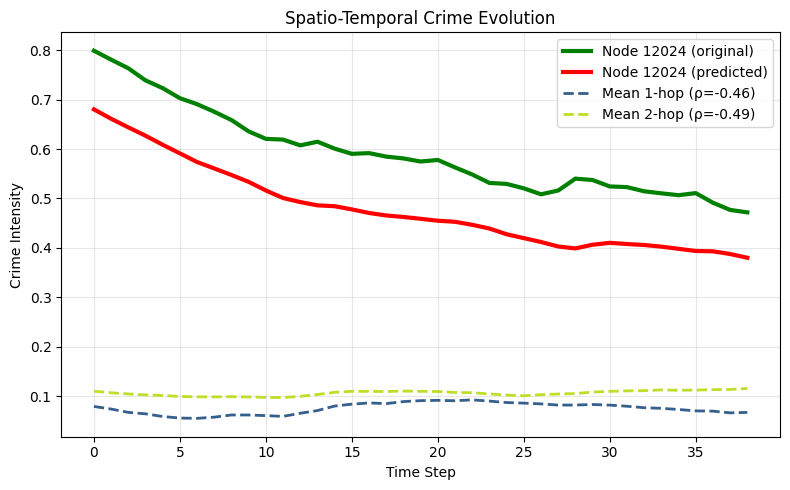

In [161]:
pred_matrix = np.stack(preds_per_t)

high_node = find_peak_valley_peak_node(pred_matrix)

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_peak_valley_node_{high_node}')



## Fluctuation by curvature

In [162]:
def fluctuation_by_curvature(pred_matrix):
    T, N = pred_matrix.shape
    curvature_scores = np.zeros(N)

    for n in range(N):
        series = pred_matrix[:, n]
        second_derivative = np.diff(series, n=0)
        curvature_scores[n] = np.sum(np.abs(second_derivative))

    return np.argmax(curvature_scores)


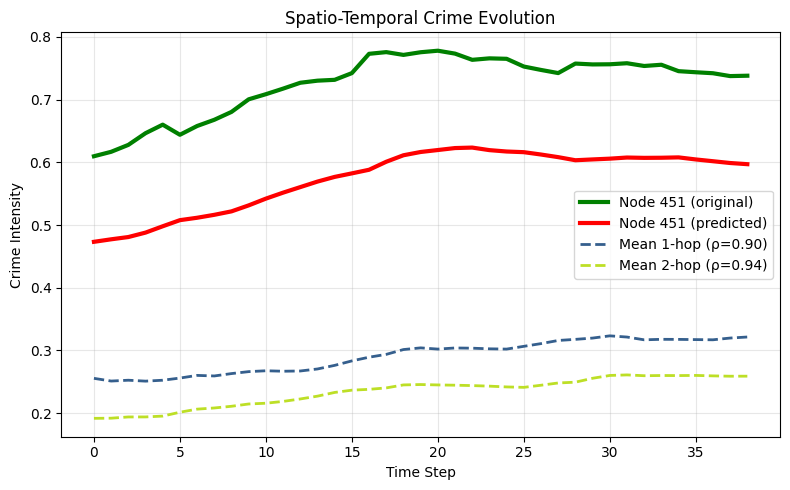

In [163]:
pred_matrix = np.stack(preds_per_t)

# node_2 = find_clean_fluctuation_node(pred_matrix)
high_node = fluctuation_by_curvature(pred_matrix)
# high_node = 12024 #5649

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_fluctuation_curvature_node_{high_node}')




# Modality Contribution

## Ablation approach

In [164]:
full_loss, _,_ = evaluate_and_collect(model, test_loader,"cpu")
static_only_loss = ablation_evaluate(model, test_loader, criterion, mode="static")
dynamic_only_loss = ablation_evaluate(model, test_loader, criterion, mode="dynamic")
print("Ablation results:")

print(f"Full model      : {full_loss['MSE']:.4f}")
print(f"Static only     : {static_only_loss:.4f}")
print(f"Dynamic only    : {dynamic_only_loss:.4f}")


Ablation results:
Full model      : 0.0003
Static only     : 0.0039
Dynamic only    : 0.0002


In [165]:
# results

In [166]:
import pandas as pd

# Create results table
results_ablation = pd.DataFrame({
    "Model": ["Full model", "Static only", "Dynamic only"],
    "MSE": [
        metrics["MSE"],
        static_only_loss,
        dynamic_only_loss
    ]
})

# Save to CSV
results_ablation.to_csv(f"{output_folder}/ablation_results_{model_used}.csv", index=False)

print("Saved to ablation_results.csv")

Saved to ablation_results.csv


In [167]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(len(alpha_self_history))


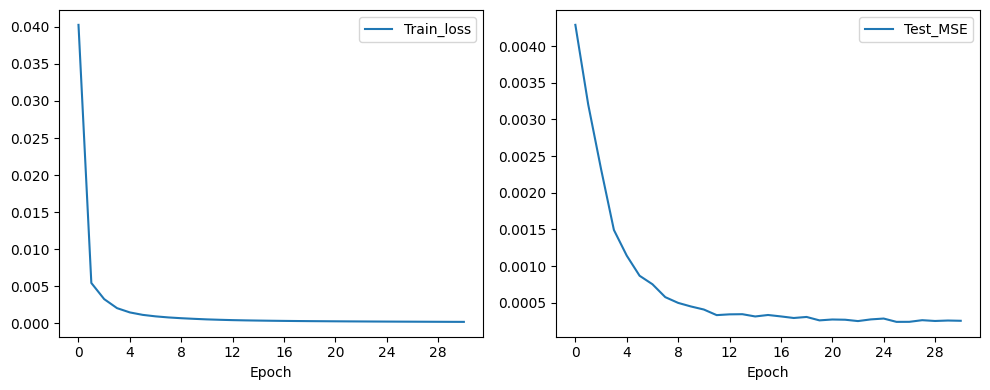

In [168]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_per_epoch, label="Train_loss")
# plt.plot(epochs, [1 - a for a in alpha_self_history], label="Dynamic", linestyle="--")
# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
# plt.title("Self Contribution")
plt.xlabel("Epoch")
# plt.ylabel("Weight")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
mse_values = [d['MSE'] for d in test_loss_per_epoch]
plt.plot(epochs, mse_values, label="Test_MSE")
# plt.plot(epochs, [1 - a for a in alpha_neigh_history], label="Dynamic", linestyle="--")

# plt.ylim(0, 1)  # Y-axis from 0 to 1
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
# plt.title("Neighbor Contribution")
plt.xlabel("Epoch")
plt.legend()
# plt.grid(True)

plt.tight_layout()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"Train_test_Loss.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


# Embedding projection

In [169]:
# x_dynamic_window = test_dataset.x_dynamic[:, -3:]  # last 3 months

# model.eval()
# _, embeddings = model(
#     test_dataset.x_static,
#     x_dynamic_window,
#     test_dataset.edge_index,
#     return_embedding=True
# )
# print(f"Node Embeddings shape: {embeddings.shape}")

In [170]:
# tsne = TSNE(n_components=2, random_state=seed)
# emb_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

# tsne_result = pd.DataFrame(emb_2d)
# tsne_result.to_csv(f"{output_folder}/tsne_output_{model_used}_{type_graph_conv}_{architecture}.csv", index=False)

In [171]:
# def plot_embedding(emb_2d, filename= 'embedding', output_path = None):
#     df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])

#     plt.figure(figsize=figsize)
#     sns.scatterplot(data=df_emb, x='x', y='y', palette='Set1')
#     # Save or show
#     if output_path:
#         file_path = os.path.join(output_path, f"{filename}.{save_format}")
#         plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
#         plt.show()
#         plt.close()
#     else:
#         plt.show()
#         plt.close()

In [172]:
# def plot_embedding_label(emb_2d, crime_label_tensor, filename= 'embedding', output_path = None):
#     df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])
#     df_emb['label'] = crime_label_tensor

#     plt.figure(figsize=figsize)
#     sns.scatterplot(data=df_emb, x='x', y='y', hue='label', palette='Set1')
#     # Save or show
#     if output_path:
#         file_path = os.path.join(output_path, f"{filename}.{save_format}")
#         plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
#         plt.show()
#         plt.close()
#     else:
#         plt.show()
#         plt.close()

In [173]:
# plot_embedding(emb_2d, filename= f'embedding_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)

In [174]:
# plot_embedding_label(emb_2d, crime_label_col, filename= f'embedding_with_label_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)
